In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

plt.style.use('default')
sns.set_theme()

print("Libraries Imported Successfully")

df = pd.read_csv(
    "Country-data.csv"
)

print(df.shape)

print(df.columns.tolist())

df.head()

df.info()

df.isnull().sum()

Libraries Imported Successfully
(167, 10)
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='str')


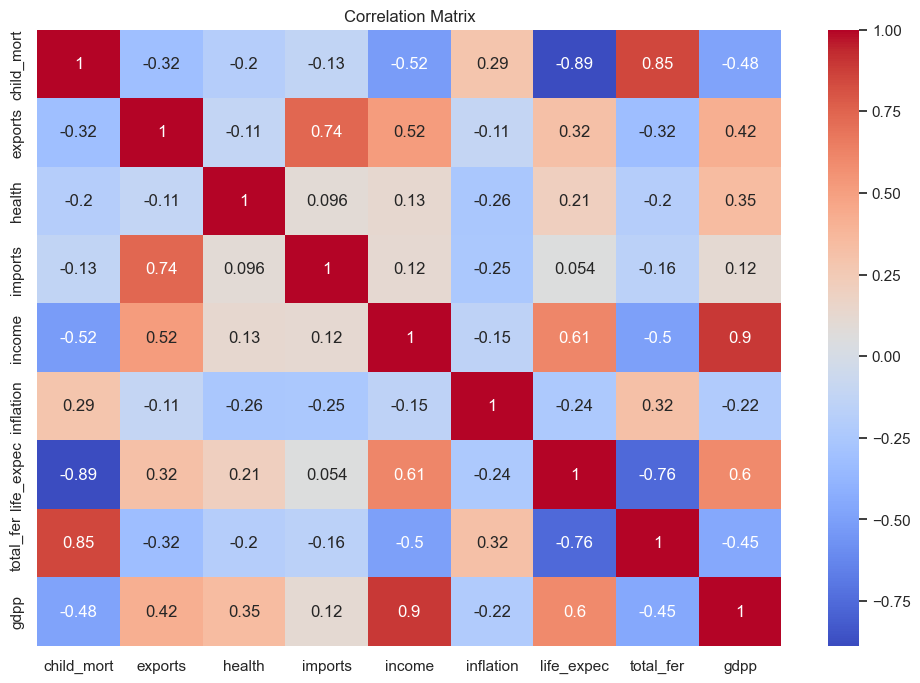

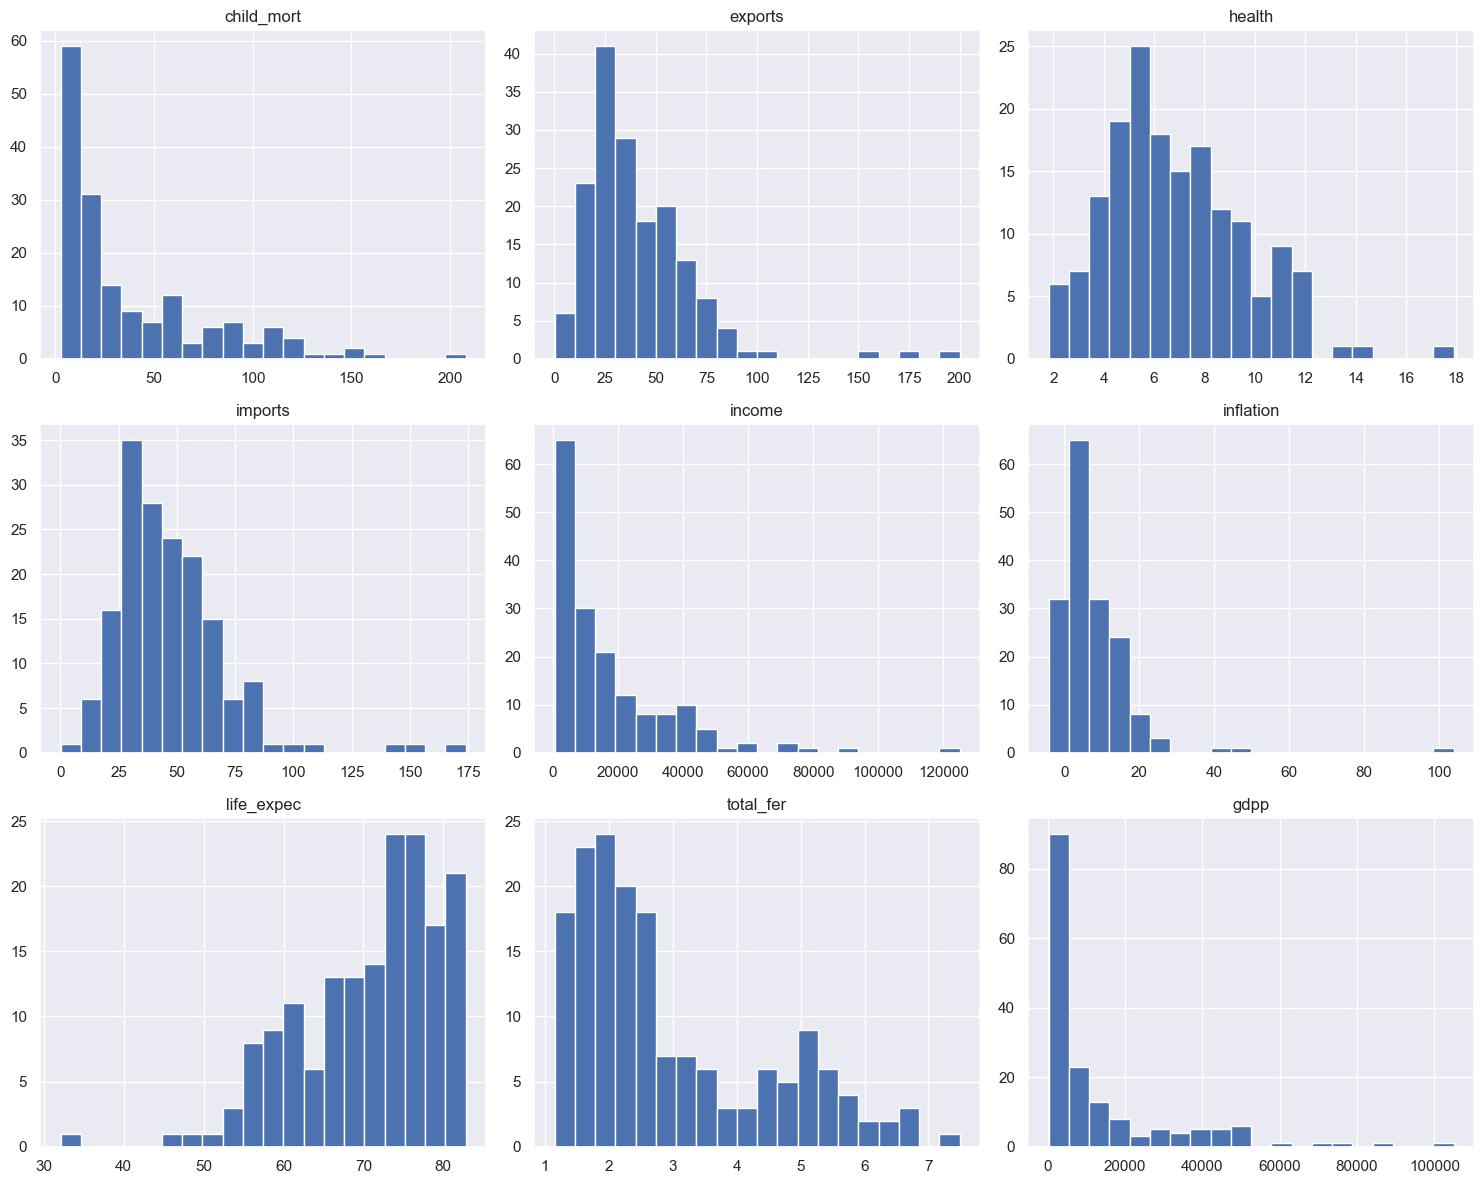

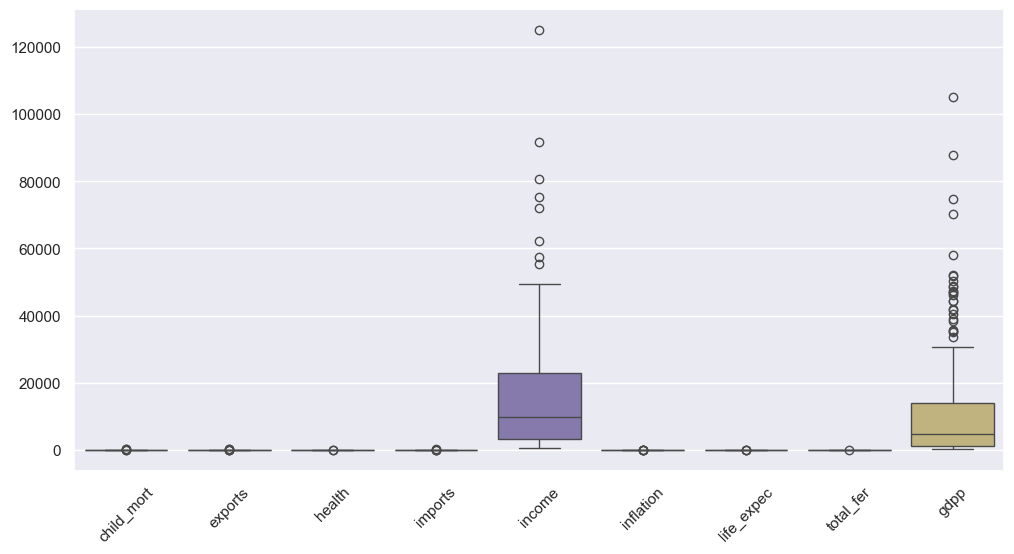

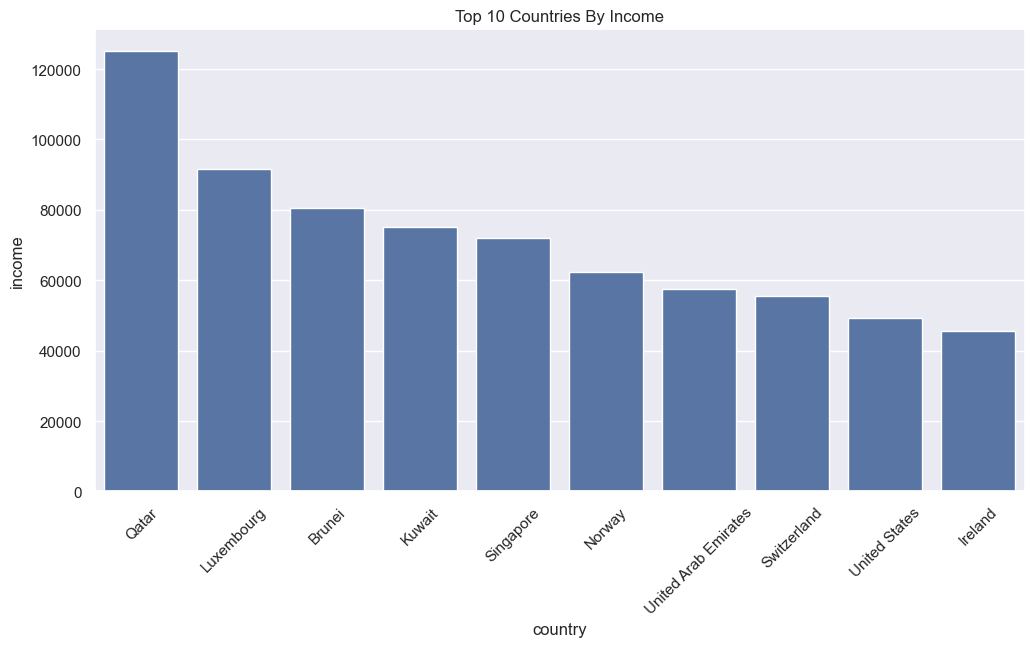

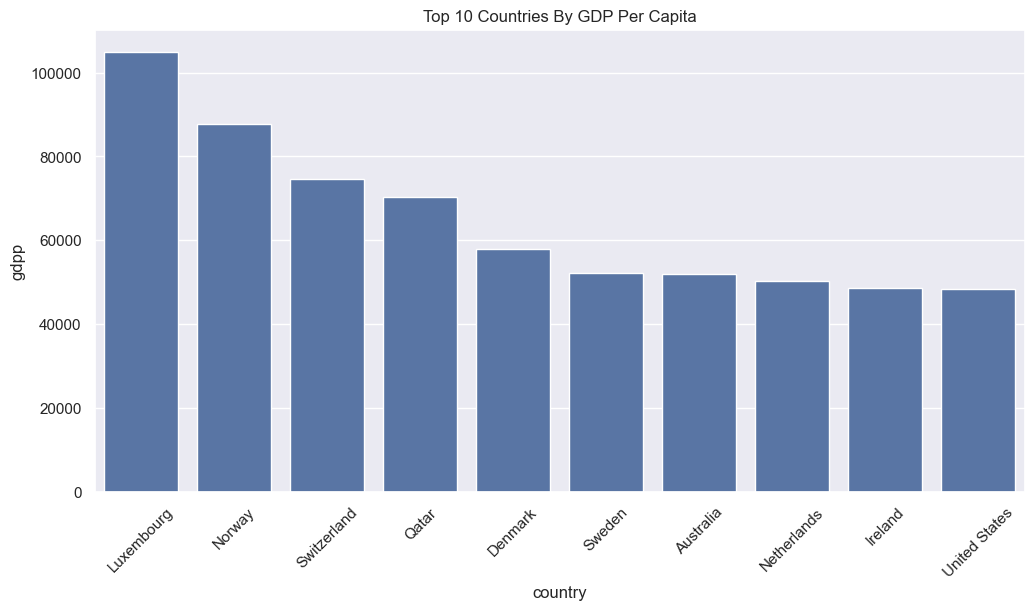

In [9]:
numeric_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns

print(numeric_columns)

plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Matrix'
)

plt.show()

df[numeric_columns].hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()

plt.show()

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[numeric_columns]
)

plt.xticks(rotation=45)

plt.show()

top_income = df.sort_values(
    'income',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='country',
    y='income',
    data=top_income
)

plt.xticks(rotation=45)

plt.title(
    'Top 10 Countries By Income'
)

plt.show()

top_gdpp = df.sort_values(
    'gdpp',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='country',
    y='gdpp',
    data=top_gdpp
)

plt.xticks(rotation=45)

plt.title(
    'Top 10 Countries By GDP Per Capita'
)

plt.show()

In [10]:
X = df.drop(
    'country',
    axis=1
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print(X_scaled.shape)

print(X_scaled.head())

(167, 9)
   child_mort   exports    health   imports    income  inflation  life_expec  \
0    1.291532 -1.138280  0.279088 -0.082455 -0.808245   0.157336   -1.619092   
1   -0.538949 -0.479658 -0.097016  0.070837 -0.375369  -0.312347    0.647866   
2   -0.272833 -0.099122 -0.966073 -0.641762 -0.220844   0.789274    0.670423   
3    2.007808  0.775381 -1.448071 -0.165315 -0.585043   1.387054   -1.179234   
4   -0.695634  0.160668 -0.286894  0.497568  0.101732  -0.601749    0.704258   

   total_fer      gdpp  
0   1.902882 -0.679180  
1  -0.859973 -0.485623  
2  -0.038404 -0.465376  
3   2.128151 -0.516268  
4  -0.541946 -0.041817  


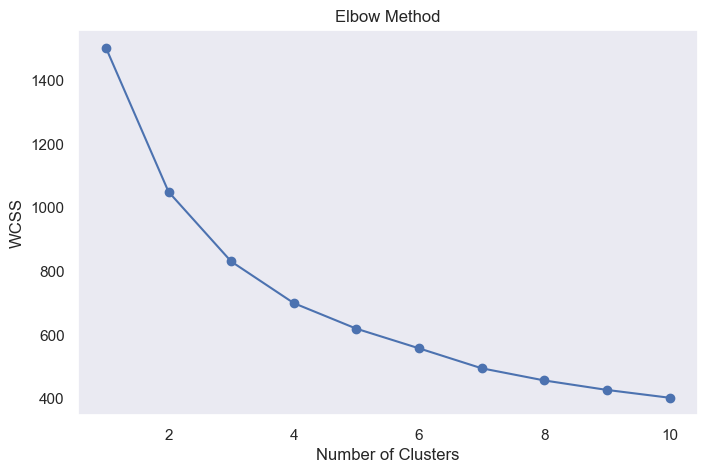

Cluster
2    84
1    47
0    36
Name: count, dtype: int64


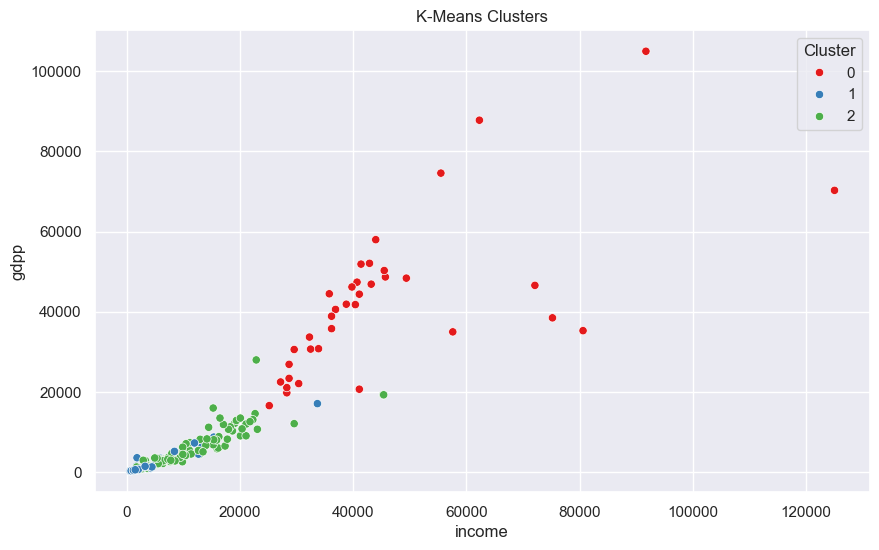

         child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
1         92.961702  29.151277  6.388511  42.323404   3942.404255  12.019681   
2         21.927381  40.243917  6.200952  47.473404  12305.595238   7.600905   

         life_expec  total_fer          gdpp  
Cluster                                       
0         80.127778   1.752778  42494.444444  
1         59.187234   5.008085   1922.382979  
2         72.814286   2.307500   6486.452381  


In [11]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel('Number of Clusters')

plt.ylabel('WCSS')

plt.title('Elbow Method')

plt.grid()

plt.show()


kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_scaled
)

df['Cluster'] = clusters

print(
    df['Cluster'].value_counts()
)


plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['income'],
    y=df['gdpp'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title(
    'K-Means Clusters'
)

plt.show()


cluster_summary = df.groupby(
    'Cluster'
).mean(
    numeric_only=True
)

print(cluster_summary)

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


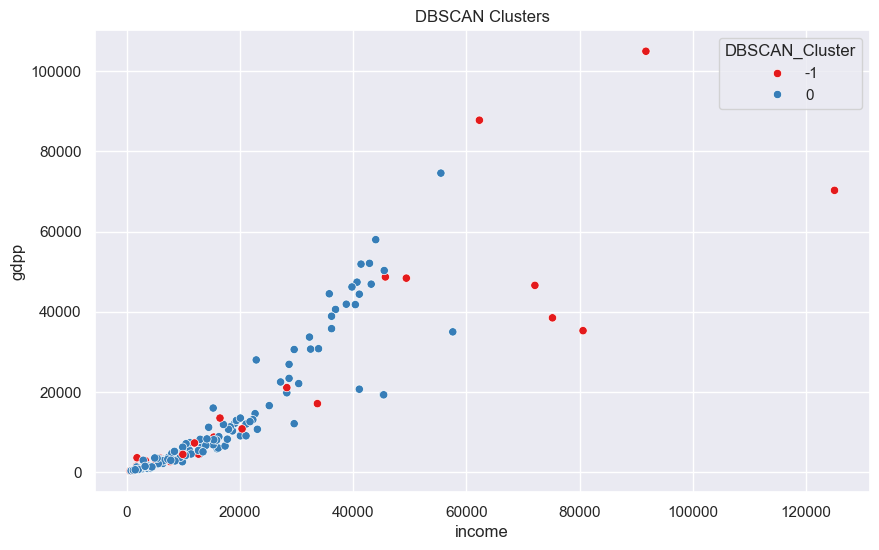

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



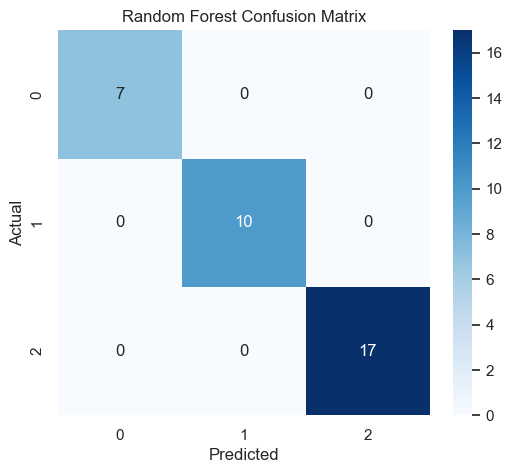

      Feature  Importance
0  child_mort    0.261935
8        gdpp    0.202125
7   total_fer    0.165920
6  life_expec    0.156307
4      income    0.146203
2      health    0.030472
5   inflation    0.014817
3     imports    0.012632
1     exports    0.009589


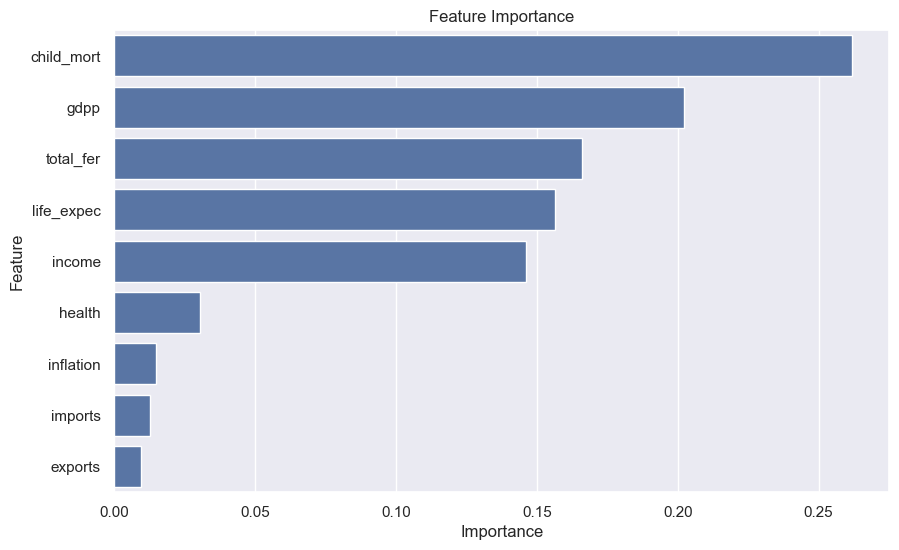

In [12]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_clusters = dbscan.fit_predict(
    X_scaled
)

df['DBSCAN_Cluster'] = dbscan_clusters

print(
    df['DBSCAN_Cluster'].value_counts()
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['income'],
    y=df['gdpp'],
    hue=df['DBSCAN_Cluster'],
    palette='Set1'
)

plt.title(
    'DBSCAN Clusters'
)

plt.show()


X = df.drop(
    ['country','Cluster','DBSCAN_Cluster'],
    axis=1
)

y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_predictions
    )
)

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()


feature_importance = pd.DataFrame(
    {
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }
)

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title(
    'Feature Importance'
)

plt.show()

XGBoost Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



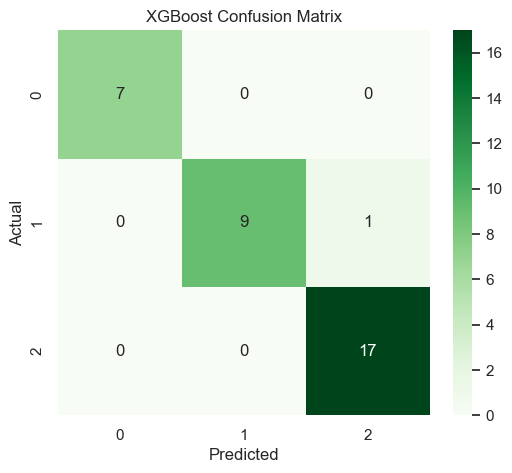

                      country  income  gdpp  child_mort  life_expec
26                    Burundi     764   231        93.6        57.7
88                    Liberia     700   327        89.3        60.8
37           Congo, Dem. Rep.     609   334       116.0        57.5
112                     Niger     814   348       123.0        58.8
132              Sierra Leone    1220   399       160.0        55.0
93                 Madagascar    1390   413        62.2        60.8
106                Mozambique     918   419       101.0        54.5
31   Central African Republic     888   446       149.0        47.5
94                     Malawi    1030   459        90.5        53.1
50                    Eritrea    1420   482        55.2        61.7
150                      Togo    1210   488        90.3        58.7
64              Guinea-Bissau    1390   547       114.0        55.6
0                 Afghanistan    1610   553        90.2        56.2
56                     Gambia    1660   562     

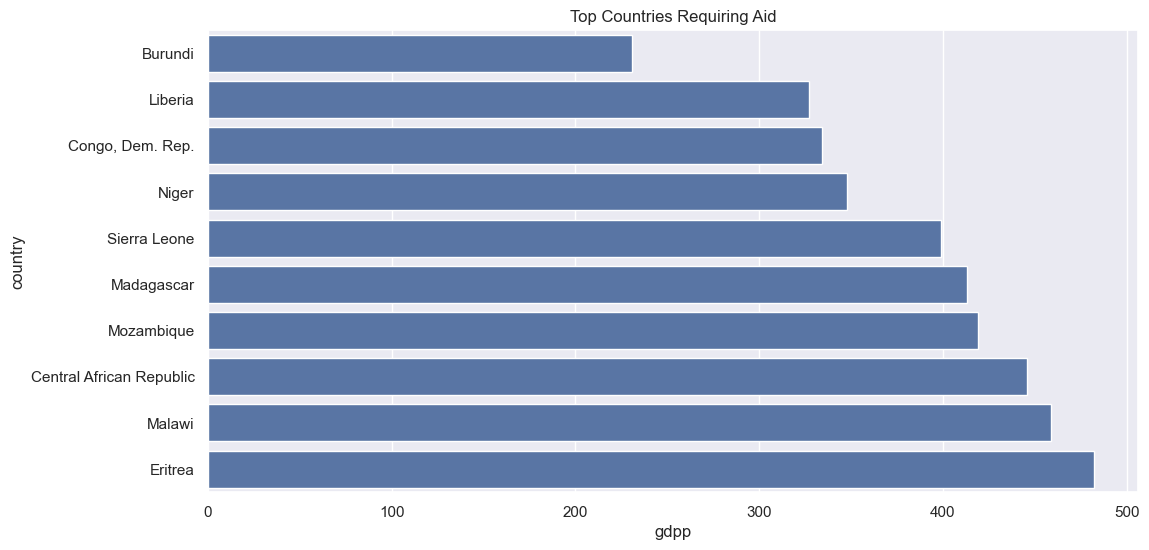

In [13]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test
)

print(
    "XGBoost Accuracy:",
    accuracy_score(
        y_test,
        xgb_predictions
    )
)

print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

xgb_cm = confusion_matrix(
    y_test,
    xgb_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'XGBoost Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()


priority_countries = df[
    df['Cluster'] == 1
]

priority_countries = priority_countries.sort_values(
    by=['gdpp','income']
)

print(
    priority_countries[
        [
            'country',
            'income',
            'gdpp',
            'child_mort',
            'life_expec'
        ]
    ].head(20)
)


top_10_focus = priority_countries[
    [
        'country',
        'income',
        'gdpp',
        'child_mort',
        'life_expec'
    ]
].head(10)

print("\nTop 10 Countries Requiring Immediate Aid\n")

print(top_10_focus)


plt.figure(figsize=(12,6))

sns.barplot(
    x='gdpp',
    y='country',
    data=top_10_focus
)

plt.title(
    'Top Countries Requiring Aid'
)

plt.show()

           Model  Accuracy
0  Random Forest  1.000000
1        XGBoost  0.970588


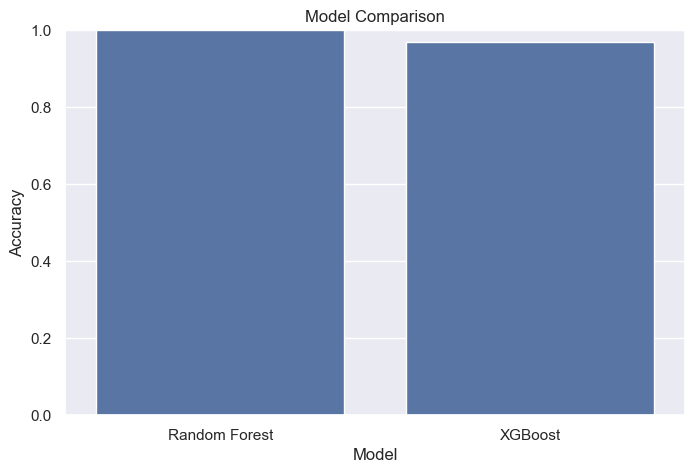

In [14]:
comparison = pd.DataFrame(
    {
        'Model': [
            'Random Forest',
            'XGBoost'
        ],
        'Accuracy': [
            accuracy_score(
                y_test,
                rf_predictions
            ),
            accuracy_score(
                y_test,
                xgb_predictions
            )
        ]
    }
)

print(comparison)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title(
    'Model Comparison'
)

plt.ylim(0,1)

plt.show()

Customer Intelligence System Using Classification, Ensemble Learning and Clustering

Objectives:
- Segment countries based on socio-economic indicators.
- Identify countries requiring immediate aid.
- Compare machine learning models for prediction.

Techniques Used:
- Exploratory Data Analysis
- StandardScaler
- K-Means Clustering
- DBSCAN Clustering
- Random Forest Classifier
- XGBoost Classifier

Results:
- Countries were grouped into developed, developing and underdeveloped segments.
- Random Forest and XGBoost achieved high classification accuracy.
- High-priority countries were identified for NGO intervention.

Conclusion:
The developed system enables data-driven decision making for resource allocation and country prioritization.